In [28]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

In [17]:
manual_df = pd.read_csv("data/sample_agent_repos_llm_filtered_withShortReadme_manual.csv")
qwen_df = pd.read_csv("data/sample_agent_repos_llm_filtered_withShortReadme_Qwen.csv")
llama_df = pd.read_csv("data/sample_agent_repos_llm_filtered_withShortReadme_llama.csv")

In [43]:
assert len(manual_df) == len(qwen_df) == len(llama_df), "CSV files must have same number of rows"

In [44]:
# Mapping variants to standard categories
category_map = {
    # Frameworks
    "framework": "agentic framework",
    "framework ": "agentic framework",
    "a security analysis / detection framework for ai agents": "agentic framework",

    # Papers / tutorials / documents
    "papers lst": "documents about llm agents",
    "tutorial": "documents about llm agents",
    "document": "documents about llm agents",

    # Benchmark
    "benchmarking": "agentic benchmark",

    # Other
    "other": "other",
    "other (checked the code)": "other",
    "orther": "other",

    # Blank / unknown
    "?": ""
}

In [45]:
# Lowercase, strip, remove multiple spaces first
manual_df["Manual"] = manual_df["Manual"].str.lower().str.strip()

# Apply mapping
manual_df["Manual_Normalized"] = manual_df["Manual"].map(category_map).fillna(manual_df["Manual"])

In [48]:
print(manual_df[["Manual", "Manual_Normalized"]].head(12))

                                               Manual  \
0                                   agentic framework   
1                           rag-based llm application   
2                            llm-based agentic system   
3                            llm-based agentic system   
4                            llm-based agentic system   
5                                            rl agent   
6                            llm-based agentic system   
7                                  llm-powered script   
8                    rl agent with llm-based planning   
9                            llm-based agentic system   
10                llm-powered recommendation pipeline   
11  a security analysis / detection framework for ...   

                      Manual_Normalized  
0                     agentic framework  
1             rag-based llm application  
2              llm-based agentic system  
3              llm-based agentic system  
4              llm-based agentic system  
5     

In [49]:
y_true = manual_df["Manual_Normalized"]
y_qwen = qwen_df["category"]
y_llama = llama_df["category"]

In [50]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n===== {model_name} Evaluation =====")

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    print("\nDetailed Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return accuracy, precision, recall, f1

In [52]:
qwen_acc, qwen_prec, qwen_rec, qwen_f1 = evaluate_model(y_true, y_qwen, "Qwen")


===== Qwen Evaluation =====
Accuracy:  0.5850
Precision: 0.0770
Recall:    0.0676
F1-score:  0.0598

Detailed Report:
                                                       precision    recall  f1-score   support

                                                            0.00      0.00      0.00         1
                                    agentic benchmark       0.00      0.00      0.00         1
                                    agentic framework       0.32      0.70      0.44        10
                                ai workflow framework       0.00      0.00      0.00         1
        both (framework and llm based sgentic system)       0.00      0.00      0.00         1
                                           collection       0.00      0.00      0.00         3
                               collection of datasets       0.00      0.00      0.00         0
                     collection of llm agent projects       0.00      0.00      0.00         0
                         

In [53]:
llama_acc, llama_prec, llama_rec, llama_f1 = evaluate_model(y_true, y_llama, "LLaMA")


===== LLaMA Evaluation =====
Accuracy:  0.5350
Precision: 0.0350
Recall:    0.0856
F1-score:  0.0448

Detailed Report:
                                                       precision    recall  f1-score   support

                                                            0.00      0.00      0.00         1
                                    agentic benchmark       0.17      1.00      0.29         1
                                    agentic framework       0.17      0.70      0.27        10
                                ai workflow framework       0.00      0.00      0.00         1
        both (framework and llm based sgentic system)       0.00      0.00      0.00         1
                                           collection       0.00      0.00      0.00         3
                               collection of datasets       0.00      0.00      0.00         0
                     collection of llm agent projects       0.00      0.00      0.00         0
                        

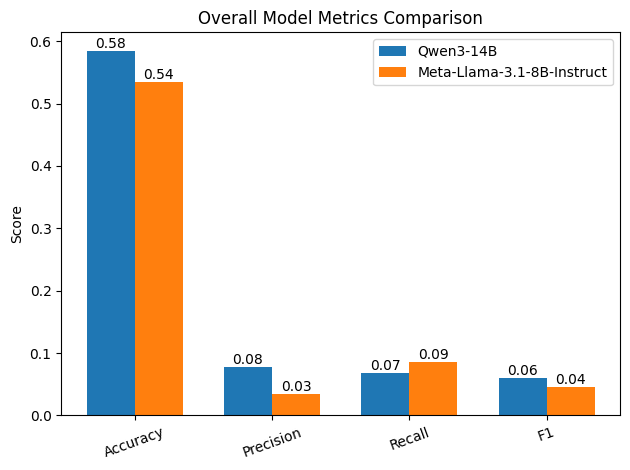

In [55]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]

qwen_scores = [qwen_acc, qwen_prec, qwen_rec, qwen_f1]
llama_scores = [llama_acc, llama_prec, llama_rec, llama_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure()
bars1 = plt.bar(x - width/2, qwen_scores, width, label="Qwen3-14B")
bars2 = plt.bar(x + width/2, llama_scores, width, label="Meta-Llama-3.1-8B-Instruct")

plt.xticks(x, metrics, rotation=20)
plt.ylabel("Score")
plt.title("Overall Model Metrics Comparison")
plt.legend()

# 🔹 Add values above bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.2f}",
             ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.2f}",
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [60]:
comparison_df = manual_df.copy()

comparison_df["Qwen_Category"] = qwen_df["category"]
comparison_df["LLaMA_Category"] = llama_df["category"]

# Mark correctness
comparison_df["Qwen_Correct"] = (
    comparison_df["Manual_Normalized"] == comparison_df["Qwen_Category"]
)

comparison_df["LLaMA_Correct"] = (
    comparison_df["Manual_Normalized"] == comparison_df["LLaMA_Category"]
)

# Mark rows where any model is wrong
comparison_df["Any_Model_Wrong"] = ~(
    comparison_df["Qwen_Correct"] & comparison_df["LLaMA_Correct"]
)

comparison_df = comparison_df.rename(
    columns={"Manual": "Manual_Category"}
)

# Save full results
comparison_df.to_csv("data/sample_with_model_results_comparison.csv", index=False)

print("\nSaved comparison to: sample_with_model_results_comparison.csv")


Saved comparison to: sample_with_model_results_comparison.csv


In [62]:
# Save only incorrect predictions
# ---------------------------------
incorrect_df = comparison_df[comparison_df["Any_Model_Wrong"] == True]

print("Total incorrect predictions:", len(incorrect_df))

Total incorrect predictions: 97
